In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,classification_report
import seaborn as sns

In [2]:
#generate systheic data for decision tree
np.random.seed(42)
#class 0 :not buy(eg,younger ,lower income)
x_dt0=np.random.normal(loc=[50,70000],scale=[10,15000],size=(60,2))
y_dt0=np.zeros(60)

#class 1;buy(eg,older,higher income)
x_dt1=np.random.normal(loc=[50,70000],scale=[10,15000],size=(60,2))
y_dt1=np.ones(60)

#combine data
x_dt=np.vstack((x_dt0,x_dt1))
y_dt=np.hstack((y_dt0,y_dt1))

#combined data
x_dt=np.vstack((x_dt0,x_dt1))
y_dt=np.hstack((y_dt0,y_dt1))

df_dt=pd.DataFrame(x_dt, columns=["Age","Income"])
df_dt["Decision"]= y_dt
display(df_dt.head())



,Age,Income,Decision
0,54.967142,67926.035482,0.0
1,56.476885,92845.447846,0.0
2,47.658466,66487.945646,0.0
3,65.792128,81511.520937,0.0
4,45.305256,78138.400654,0.0


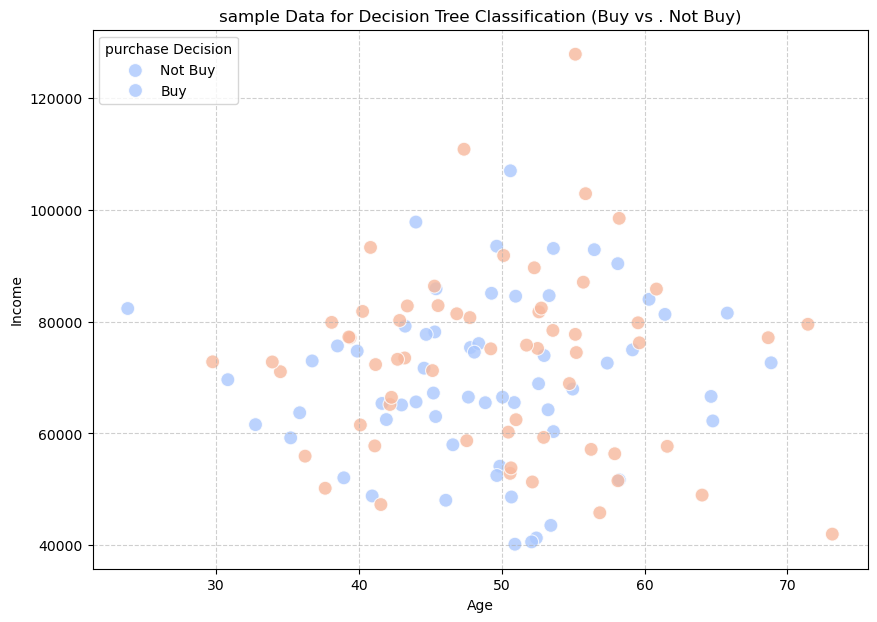

In [3]:
#plot the generated data for decision tree
plt.figure(figsize=(10,7))
sns.scatterplot(x="Age", y="Income",hue="Decision",data=df_dt,palette="coolwarm",s=100,alpha=0.8)
plt.title("sample Data for Decision Tree Classification (Buy vs . Not Buy)")
plt.xlabel('Age')
plt.ylabel('Income')
plt.grid(True,linestyle="--",alpha=0.6)
plt.legend(title="purchase Decision",loc="upper left",labels=["Not Buy","Buy"])
plt.show()
    

In [4]:
#split data for decision tree
x_dt_train,x_dt_test,y_dt_train,y_dt_test=train_test_split(x_dt,y_dt,test_size=0.3,random_state=42)
print(f"Training set shape for DT:{x_dt_train.shape},{y_dt_train.shape}")
print(f"Testing set shape for DT:{x_dt_test.shape},{y_dt_test.shape}")

Training set shape for DT:(84, 2),(84,)
Testing set shape for DT:(36, 2),(36,)


In [5]:
#Initialize decision Tree classifier
dt_classifier=DecisionTreeClassifier(max_depth=3,random_state=42)
#train the model
dt_classifier.fit(x_dt_train,y_dt_train)
print("Decision Tree Classifier trained sucessfully.")

Decision Tree Classifier trained sucessfully.


In [6]:
#make prediction on the test data
y_dt_pred=dt_classifier.predict(x_dt_test)
print("First 10 actual label for Dt:",y_dt_test[:10])
print("First 10 predicted label for Dt:",y_dt_pred[:10]) 

First 10 actual label for Dt: [0. 0. 0. 0. 0. 1. 1. 0. 0. 1.]
First 10 predicted label for Dt: [1. 1. 1. 0. 1. 0. 1. 0. 0. 1.]


In [8]:
dt_accuracy=accuracy_score(y_dt_test,y_dt_pred)
dt_report=classification_report(y_dt_test,y_dt_pred)
print(f"Decision Tree Accuracy :{dt_accuracy:.2f}")
print("Decision Tree Classification Report :\n",dt_report)

Decision Tree Accuracy :0.47
Decision Tree Classification Report :
               precision    recall  f1-score   support

         0.0       0.50      0.42      0.46        19
         1.0       0.45      0.53      0.49        17

    accuracy                           0.47        36
   macro avg       0.47      0.48      0.47        36
weighted avg       0.48      0.47      0.47        36

